In [1]:
# These take a while

!pip install --upgrade "typing_extensions>=4.10.0"
!pip install --upgrade pip
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install -q bitsandbytes sae-lens datasets matplotlib tqdm scipy seaborn scikit-learn numpy accelerate statsmodels
!pip install -q transformers accelerate
!pip install -q hf_transfer

print("Done")

  Attempting uninstall: typing_extensions
    Found existing installation: typing_extensions 4.9.0
    Uninstalling typing_extensions-4.9.0:
      Successfully uninstalled typing_extensions-4.9.0

[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 128.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.2
    Uninstalling pip-24.2:
      Successfully uninstalled pip-24.2



KeyboardInterrupt



In [2]:
# === ONLY install cell. Run once, RESTART KERNEL, then run imports. ===
%pip install --upgrade pip
%pip install -U "typing_extensions>=4.10.0"

# Torch 2.7+ — needed for torch.float8_e8m0fnu that current transformers references.
# cu128 wheels cover the L40S. This REPLACES the old cu124 line that capped you at 2.6.
%pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

# Everything the notebook imports, one resolve, bitsandbytes last so it matches torch.
# No transformer-lens pin — sae-lens pulls its own compatible version.
%pip install -U sae-lens transformers accelerate datasets hf_transfer bitsandbytes
%pip install -U matplotlib tqdm scipy seaborn scikit-learn numpy statsmodels

print("Install done. RESTART THE KERNEL now, then run the imports cell.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 657.9/657.9 MB 94.3 MB/s  0:00:08:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 83.0 MB/s  0:00:03ta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.8/296.8 MB 137.2 MB/s  0:00:02a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.1/139.1 MB 119.2 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 105.6 MB/s  0:00:0500:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 397.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 153.4 MB/s  0:00:01a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 228.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 204.6 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import torch
print(torch.__version__, "| float8_e8m0fnu present:", hasattr(torch, "float8_e8m0fnu"))
print("CUDA:", torch.cuda.is_available())

2.11.0+cu128 | float8_e8m0fnu present: True
CUDA: True


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from sae_lens import SAE
from datasets import load_dataset
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import re
import gc

In [3]:
from huggingface_hub import login
login()

In [4]:
# Setup device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

MODEL_A_ID = "google/gemma-2-2b"     
MODEL_B_ID = "google/gemma-2-9b"    

# Fixed layer pair based on previous calculations
STITCH_LAYER_A = 20   # Gemma 2B layer 20
STITCH_LAYER_B = 30  # Gemma 9B layer 30

SAE_A_RELEASE = "gemma-scope-2b-pt-res-canonical"
SAE_A_ID = f"layer_{STITCH_LAYER_A}/width_16k/canonical"  
SAE_B_RELEASE = "gemma-scope-9b-pt-res-canonical" 
SAE_B_ID = f"layer_{STITCH_LAYER_B}/width_16k/canonical" 

# [Phase 0] Oracle deltas are now collected from GSM8K-train (indices 0..N_ORACLE_SAMPLES-1),
# which is disjoint from the GSM8K test split used for evaluation.
# [Phase 1] Training data switched from OpenWebText to GSM8K-train.
TRAINING_DATASET = "openai/gsm8k"          # replaces NeelNanda/openwebtext-tokenized-9b
TRAINING_DATASET_CONFIG = "main"
TRAINING_SPLIT = "train"            # GSM8K train has ~7.5k examples
N_TRAINING_SAMPLES = 5000           # how many GSM8K-train examples to tokenize

CONTEXT_LENGTH = 128
BATCH_SIZE = 4  
NUM_EPOCHS = 8   
LEARNING_RATE = 1e-4
ACTIVATION_CACHE_SIZE = 5_000  
NUM_SAMPLES_FOR_SVCCA = 200  

# ── Phase 1 training config flags ──────────────────────────────────────────
# Bottleneck width (Phase 3 sweep: try 32, 64, 128, 256)
BOTTLENECK_DIM = 64

# Set to 0.0 to use KL-only loss (recommended default per analysis in doc).
# Set to 0.5 to restore original cycle-consistency weighting for ablation.
# Phase 3 ablation: run with CYCLE_LOSS_WEIGHT=0.5 to compare curves.
CYCLE_LOSS_WEIGHT = 0.0

# Random per-batch strength sampling range (uniform draw each batch).
# Recommended: [0.3, 1.0]. Matches the hook used at eval time.
STRENGTH_SAMPLE_MIN = 0.3
STRENGTH_SAMPLE_MAX = 1.0

# Oracle-in-training: keep False so the trained stitch isn't coupled to a
# specific oracle rank -> Phase 3's rank sweep works from one trained stitch.
# Flip to True in Phase 3 if you want to test oracle-guided training.
APPLY_ORACLE_IN_TRAINING = False

# Number of GSM8K-train samples used for oracle delta collection (Phase 0).
# These indices MUST NOT overlap with evaluation indices (GSM8K test split).
# GSM8K train and test are separate HF splits, so there is zero overlap.
N_ORACLE_SAMPLES = 100


ORACLE_RANK_FOR_TRAINING = 32   # set based on Phase 1 sweep results

Using device: cuda


In [5]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

print("Loading tokenizer and models...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_A_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'   # required for correct batched generate at eval

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True
)

# Load Model A (2B model)
print(f"Loading {MODEL_A_ID}...")
model_a = AutoModelForCausalLM.from_pretrained(
    MODEL_A_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    low_cpu_mem_usage=True
)

# Load Model B (9B model)
print(f"Loading {MODEL_B_ID}...")
model_b = AutoModelForCausalLM.from_pretrained(
    MODEL_B_ID,
    torch_dtype=torch.bfloat16,
    quantization_config=bnb_config,  # <-- NEW WAY TO PASS 4-BIT PARAMS
    device_map="auto",
    low_cpu_mem_usage=True
)

print("Models and tokenizer loaded successfully.")
print(f"Using fixed layer pair: Gemma 2B Layer {STITCH_LAYER_A} → Gemma 9B Layer {STITCH_LAYER_B}")

def get_unnormalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get unnormalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        # Handle different model architectures
        if hasattr(model, 'model'):
            # For Gemma models
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Return all sequence positions: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            return all_activations.view(-1, hidden_dim).cpu()
        else:
            # Return only last token: [batch_size, hidden_dim] 
            return all_activations[:, -1].cpu()

def get_normalized_activations(model, tokens, layer_idx, return_all_positions=False):
    """
    Get normalized activations. Can return all positions or just the last token.
    """
    with torch.no_grad():
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
            
        # Shape: [batch_size, seq_len, hidden_dim]
        all_activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        if return_all_positions:
            # Normalize per position, return all: [batch_size * seq_len, hidden_dim]
            batch_size, seq_len, hidden_dim = all_activations.shape
            # Reshape to process all positions at once
            reshaped = all_activations.view(-1, hidden_dim)
            normalized = torch.nn.functional.layer_norm(reshaped, [hidden_dim])
            return normalized.cpu()
        else:
            # Normalize and return only last token: [batch_size, hidden_dim]
            last_token_acts = all_activations[:, -1]  
            normalized_activations = torch.nn.functional.layer_norm(last_token_acts, [last_token_acts.shape[-1]])
            return normalized_activations.cpu()
        
        
def get_sae_features(model, sae, tokens, layer_idx):
    """Get SAE feature activations instead of raw activations"""
    with torch.no_grad():
        # Get unnormalized activations (SAEs expect these)
        if hasattr(model, 'model'):
            outputs = model.model(tokens, output_hidden_states=True)
        else:
            outputs = model(tokens, output_hidden_states=True)
        
        activations = outputs.hidden_states[layer_idx].to(torch.float32)
        
        # Encode through SAE to get features
        features = sae.encode(activations[:, -1])  # [batch, d_sae]
        return features.cpu()



def centered_kernel_alignment(acts_a, acts_b, device):
    """
    Centered Kernel Alignment (CKA) for similarity measurement
    """
    acts_a = acts_a.to(device)
    acts_b = acts_b.to(device)
    
    # Center the data
    acts_a = acts_a - acts_a.mean(dim=0, keepdim=True)
    acts_b = acts_b - acts_b.mean(dim=0, keepdim=True)
    
    # Compute Gram matrices
    gram_a = torch.mm(acts_a, acts_a.T)
    gram_b = torch.mm(acts_b, acts_b.T)
    
    # Center the Gram matrices
    n = gram_a.shape[0]
    H = torch.eye(n, device=device) - torch.ones(n, n, device=device) / n
    gram_a_centered = torch.mm(torch.mm(H, gram_a), H)
    gram_b_centered = torch.mm(torch.mm(H, gram_b), H)
    
    # CKA formula
    numerator = torch.trace(torch.mm(gram_a_centered, gram_b_centered))
    denominator = torch.sqrt(torch.trace(torch.mm(gram_a_centered, gram_a_centered)) * 
                           torch.trace(torch.mm(gram_b_centered, gram_b_centered)))
    
    if denominator > 1e-8:
        cka_score = (numerator / denominator).item()
    else:
        cka_score = 0.0
    
    return abs(cka_score)

class ActivationDataset(Dataset):
    def __init__(self, acts_a_tensor, acts_b_tensor):
        self.acts_a = acts_a_tensor
        self.acts_b = acts_b_tensor
    
    def __len__(self): 
        return self.acts_a.shape[0]
    
    def __getitem__(self, idx): 
        return self.acts_a[idx], self.acts_b[idx]

print("Loading Gemma Scope SAEs for evaluation...")

try:
    print(f"Loading SAE A: {SAE_A_RELEASE}/{SAE_A_ID}")
    sae_a: SAE = SAE.from_pretrained(release=SAE_A_RELEASE, sae_id=SAE_A_ID, device=device)
    
    print(f"Loading SAE B: {SAE_B_RELEASE}/{SAE_B_ID}")
    sae_b: SAE = SAE.from_pretrained(release=SAE_B_RELEASE, sae_id=SAE_B_ID, device=device)
    
    print("SAEs loaded successfully!")
    print(f"SAE A (Layer {STITCH_LAYER_A}): d_in={sae_a.cfg.d_in}, d_sae={sae_a.cfg.d_sae}")
    print(f"SAE B (Layer {STITCH_LAYER_B}): d_in={sae_b.cfg.d_in}, d_sae={sae_b.cfg.d_sae}")
    
except Exception as e:
    print(f"Warning: Could not load SAEs - {e}")
    print("Evaluation will proceed without SAE reconstruction")
    sae_a, sae_b = None, None


# Freeze base models and SAEs (New with KL divergence updates)
print("Freezing base models and SAEs:")

for param in sae_a.parameters():
    param.requires_grad = False
for param in sae_b.parameters():
    param.requires_grad = False
for param in model_a.parameters():
    param.requires_grad = False
for param in model_b.parameters():
    param.requires_grad = False

print("All base model and SAE parameters frozen.")

Loading tokenizer and models...


config.json:   0%|          | 0.00/818 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Models and tokenizer loaded successfully.
Using fixed layer pair: Gemma 2B Layer 20 → Gemma 9B Layer 30
Loading Gemma Scope SAEs for evaluation...
Loading SAE A: gemma-scope-2b-pt-res-canonical/layer_20/width_16k/canonical


layer_20/width_16k/average_l0_71/params.(…):   0%|          | 0.00/302M [00:00<?, ?B/s]

Loading SAE B: gemma-scope-9b-pt-res-canonical/layer_30/width_16k/canonical


layer_30/width_16k/average_l0_120/params(…):   0%|          | 0.00/470M [00:00<?, ?B/s]

SAEs loaded successfully!
SAE A (Layer 20): d_in=2304, d_sae=16384
SAE B (Layer 30): d_in=3584, d_sae=16384
Freezing base models and SAEs:
All base model and SAE parameters frozen.


In [6]:
# Fixed GSM8K prompt + numeric extraction

import re
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

MAX_NEW_TOKENS = 400
EVAL_BATCH_SIZE = 8
grafting_context = {}


def generate_gsm8k_prompt(question):
    """
    Few-shot prompt with worked example.
    use the #### format for final answers.
    """
    prompt = (
        "Below are math problems with detailed step-by-step solutions.\n\n"
        "Problem: Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. "
        "How many clips did Natalia sell altogether in April and May?\n"
        "Solution: Let's think step-by-step.\n"
        "1. Clips sold in April: 48\n"
        "2. Clips sold in May: 48 / 2 = 24\n"
        "3. Total clips: 48 + 24 = 72\n"
        "#### 72\n\n"
        f"Problem: {question}\n"
        "Solution: Let's think step-by-step."
    )
    return prompt


def extract_numerical_answer(text):
    """
    Handles standard GSM8K #### format,
    'the answer is X', and last-number fallback.
    """
    # Standard GSM8K format: #### 123
    ans_match = re.search(r"####\s*(-?[\d,.]+)", text)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Fallback: 'The answer is X'
    ans_match = re.search(r"answer is\s*(-?[\d,.]+)", text, re.IGNORECASE)
    if ans_match:
        ans_str = ans_match.group(1).replace(",", "")
        try:
            return float(ans_str)
        except ValueError:
            pass

    # Final fallback: last number in the entire text
    numbers = re.findall(r"-?[\d,.]+", text)
    if numbers:
        last_num = numbers[-1].rstrip('.').replace(",", "")
        try:
            return float(last_num)
        except ValueError:
            return None

    return None


print("Corrected eval functions defined.")

Corrected eval functions defined.


In [7]:
# Modified grafting hook with oracle projection — canonical definition
# (re-defines dynamic_grafting_hook_projected from the forward-decl cell;
#  this version is what the eval path (cell 15) picks up at runtime.)
#
# [Bug 2 fix] `with torch.no_grad():` removed — see forward-decl cell for rationale.

def dynamic_grafting_hook_projected(module, args, output):
    """Hook that applies oracle-projected grafting."""
    is_tuple = isinstance(output, tuple)
    original_activation = output[0] if is_tuple else output

    strength = grafting_context.get('strength', 0.0)
    grafted_activation = grafting_context.get('current_grafted_activation', None)

    if strength == 0.0 or grafted_activation is None:
        return output

    if original_activation.shape[1] != grafted_activation.shape[1]:
        return output

    target_dtype = next(module.parameters()).dtype

    # No torch.no_grad() — gradients must flow during training.
    # At eval time, model_a.generate() wraps everything in no_grad already.
    orig_f = original_activation.float()
    graft_f = grafted_activation.float()

    # [Scale-fix diagnostic] One-shot per-token L2 norm print (see forward-decl
    # cell for full rationale).  Armed by evaluate_gsm8k_projected when
    # strength > 0; self-disarms after the first prefill.  Placed BEFORE the
    # optional rescale so the printed ratio is the raw decoder output.
    if grafting_context.get('debug_norms', False):
        on = orig_f.norm(dim=-1)
        gn = graft_f.norm(dim=-1)
        print(
            f"[norms] orig L2 mean={on.mean():.2f} median={on.median():.2f} | "
            f"graft L2 mean={gn.mean():.2f} median={gn.median():.2f} | "
            f"graft/orig mean ratio={(gn.mean() / on.mean().clamp(min=1e-6)):.3f}"
        )
        grafting_context['debug_norms'] = False

    # [Optional second fix — OFF by default] Per-token rescale graft -> orig norm.
    # Enable with grafting_context['rescale_graft']=True only if the diagnostic
    # shows graft still meaningfully smaller than orig.
    if grafting_context.get('rescale_graft', False):
        graft_f = graft_f * (
            orig_f.norm(dim=-1, keepdim=True)
            / graft_f.norm(dim=-1, keepdim=True).clamp(min=1e-6)
        )

    # Project delta onto oracle subspace
    Br = grafting_context.get('oracle_basis', None)
    if Br is not None:
        delta_hat = graft_f - orig_f                              # [B, T, d_model]
        Br_dev = Br.to(dtype=delta_hat.dtype, device=delta_hat.device)
        coeffs = torch.einsum('btd,dr->btr', delta_hat, Br_dev)  # [B, T, r]
        delta_proj = torch.einsum('btr,dr->btd', coeffs, Br_dev) # [B, T, d_model]
        graft_f = orig_f + delta_proj

    # Blend
    modified_activation = (1 - strength) * orig_f + strength * graft_f
    modified_activation = modified_activation.to(dtype=target_dtype)

    return (modified_activation,) + output[1:] if is_tuple else modified_activation


print("Oracle-projected grafting hook defined (eval-canonical).")

Oracle-projected grafting hook defined (eval-canonical).


In [8]:
# ============================================================================
# LINEAR-STITCH BRIDGE: replace the SAE/bottleneck stitch with a closed-form
# ridge map  9B resid (L_B) -> 2B resid (L_A), fit on GSM8K-TRAIN activations.
# No SAE anywhere. recon_cos = how faithfully the map rebuilds the 2B's OWN
# state at the graft layer (the diagnostic that splits "SAE was the culprit"
# from "GSM8K states don't align cross-model").
# ============================================================================
import torch
from datasets import load_dataset

LIN_LAYER_A = STITCH_LAYER_A   # 2B graft layer (20), fixed
LIN_LAYER_B = 34               # 9B donor layer. 34 = validated best-aligned with 2B-20.
                               # Set to 30 to match the original SAE/raw-stitch layers exactly.
N_FIT_PROMPTS = 150
MAX_FIT_ROWS  = 20000
RIDGE_LAMBDA  = 1e3
RECON_HELDOUT = 40

def _collect_pair_acts(prompts, layer_b, layer_a, batch_size=4, max_rows=None):
    """Paired (X9 [N,3584], X2 [N,2304]) residuals at the graft layers,
    over non-pad token positions."""
    X9, X2, rows = [], [], 0
    model_a.eval(); model_b.eval()
    for i in tqdm(range(0, len(prompts), batch_size), desc="collect pairs"):
        enc = tokenizer(prompts[i:i+batch_size], return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(device)
        m = enc['attention_mask'].bool()
        with torch.no_grad():
            base_b = model_b.model if hasattr(model_b, 'model') else model_b
            base_a = model_a.model if hasattr(model_a, 'model') else model_a
            hb = base_b(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states[layer_b + 1].float()
            ha = base_a(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states[layer_a + 1].float()
        X9.append(hb[m].cpu()); X2.append(ha[m].cpu())
        rows += int(m.sum())
        if max_rows and rows >= max_rows:
            break
    return torch.cat(X9), torch.cat(X2)

_train = list(load_dataset("openai/gsm8k", "main", split="train")
              .select(range(N_FIT_PROMPTS + RECON_HELDOUT)))
_fit_prompts   = [generate_gsm8k_prompt(x['question']) for x in _train[:N_FIT_PROMPTS]]
_recon_prompts = [generate_gsm8k_prompt(x['question']) for x in _train[N_FIT_PROMPTS:]]

print(f"Fitting linear map  9B L{LIN_LAYER_B} -> 2B L{LIN_LAYER_A}  on GSM8K-train...")
X9, X2 = _collect_pair_acts(_fit_prompts, LIN_LAYER_B, LIN_LAYER_A, max_rows=MAX_FIT_ROWS)
print(f"  fit rows: {X9.shape[0]}  (9B {X9.shape[1]} -> 2B {X2.shape[1]})")

mu9, mu2 = X9.mean(0), X2.mean(0)
A, B = X9 - mu9, X2 - mu2
W = torch.linalg.solve(A.T @ A + RIDGE_LAMBDA * torch.eye(A.shape[1]), A.T @ B)
print("  ridge map fit.")

class LinearStitch:
    """Callable drop-in for the trained stitch: 9B resid -> 2B resid."""
    def __init__(self, W, mu9, mu2, device):
        self.W = W.to(device); self.mu9 = mu9.to(device); self.mu2 = mu2.to(device)
    def __call__(self, x):
        x = x.float().to(self.W.device)
        return (x - self.mu9) @ self.W + self.mu2
    def eval(self): return self

linear_stitch = LinearStitch(W, mu9, mu2, device)

# recon_cos on held-out GSM8K-train prompts
H9, H2 = _collect_pair_acts(_recon_prompts, LIN_LAYER_B, LIN_LAYER_A)
mapped = linear_stitch(H9).cpu()
recon_cos = torch.nn.functional.cosine_similarity(mapped, H2, dim=1).mean().item()
print(f"\nrecon_cos (mapped 9B vs 2B's own L{LIN_LAYER_A} state, held-out) = {recon_cos:.3f}")
print("  ~0.97 like arithmetic -> faithful reconstruction; injection should NOT degrade.")
print("  much lower            -> GSM8K states don't align cross-model; degradation is intrinsic.")
del X9, X2, A, B, H9, H2, mapped; torch.cuda.empty_cache()

README.md:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Fitting linear map  9B L34 -> 2B L20  on GSM8K-train...


collect pairs:   0%|          | 0/38 [00:00<?, ?it/s]

  fit rows: 20290  (9B 3584 -> 2B 2304)
  ridge map fit.


collect pairs:   0%|          | 0/10 [00:00<?, ?it/s]


recon_cos (mapped 9B vs 2B's own L20 state, held-out) = 0.953
  ~0.97 like arithmetic -> faithful reconstruction; injection should NOT degrade.
  much lower            -> GSM8K states don't align cross-model; degradation is intrinsic.


linear s=0:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0: acc = 0.260 (52/200)


linear s=0.1:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0.1: acc = 0.275 (55/200)


linear s=0.3:   0%|          | 0/25 [00:00<?, ?it/s]

...

-> LINEAR strength 0.7: acc = 0.275 (55/200)


linear s=0.9:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0.9: acc = 0.270 (54/200)


linear s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 1.0: acc = 0.275 (55/200)

=== LINEAR-STITCH sweep (no SAE) ===
recon_cos = 0.953
  strength   0: acc 0.260
  strength 0.1: acc 0.275
  strength 0.3: acc 0.280
  strength 0.5: acc 0.265
  strength 0.7: acc 0.275
  strength 0.9: acc 0.270
  strength 1.0: acc 0.275

 flat at the s=0 baseline -> faithful reconstruct, SAE caused the degradation.
 still drops with strength -> cross-model foreignness / GSM8K states don't align.
saved linear_stitch_results.json + linear_stitch_sweep.png


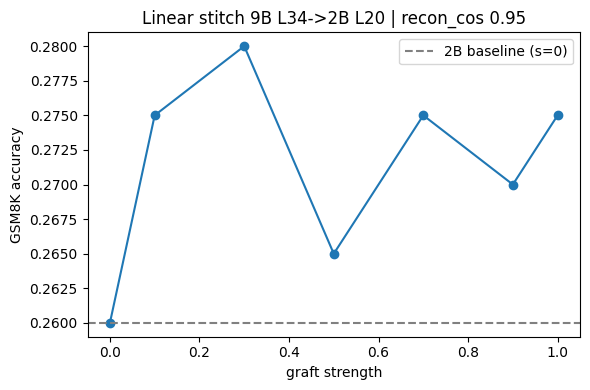

In [9]:
import matplotlib.pyplot as plt
from datasets import load_dataset

def evaluate_gsm8k_linear(stitch, samples, strength=1.0, batch_size=EVAL_BATCH_SIZE):
    correct = total = 0
    target_layer = model_a.model.layers[LIN_LAYER_A]
    target_layer._forward_hooks.clear()
    handle = target_layer.register_forward_hook(dynamic_grafting_hook_projected)
    grafting_context['oracle_basis'] = None
    grafting_context['rescale_graft'] = False
    grafting_context['strength'] = strength
    model_a.eval(); model_b.eval()
    
    try:
        for i in tqdm(range(0, len(samples), batch_size), desc=f"linear s={strength}"):
            b = samples[i:i+batch_size]
            prompts = [generate_gsm8k_prompt(x['question']) for x in b]
            gold = [extract_numerical_answer(x['answer']) for x in b]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True,
                               truncation=True, max_length=512).to(device)
            with torch.no_grad():
                if strength > 0.0:
                    base_b = model_b.model if hasattr(model_b, 'model') else model_b
                    ob = base_b(inputs['input_ids'], attention_mask=inputs['attention_mask'],
                                output_hidden_states=True)
                    grafting_context['current_grafted_activation'] = stitch(
                        ob.hidden_states[LIN_LAYER_B + 1])
                else:
                    grafting_context['current_grafted_activation'] = None
                gen = model_a.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id)
            resp = tokenizer.batch_decode(gen[:, inputs['input_ids'].shape[1]:],
                                          skip_special_tokens=True)
            for j, r in enumerate(resp):
                p = extract_numerical_answer(r)
                correct += int(p is not None and gold[j] is not None and abs(p - gold[j]) < 0.01)
                total += 1
    finally:
        handle.remove()
        grafting_context.update(strength=0.0, current_grafted_activation=None)
        
    acc = correct / total if total else 0.0
    print(f"-> LINEAR strength {strength}: acc = {acc:.3f} ({correct}/{total})")
    return acc

eval_samples = list(load_dataset("openai/gsm8k", "main", split="test").select(range(200)))
STRENGTHS = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
linear_results = {s: evaluate_gsm8k_linear(linear_stitch, eval_samples, strength=s) for s in STRENGTHS}

print("\n=== LINEAR-STITCH sweep (no SAE) ===")
print(f"recon_cos = {recon_cos:.3f}")
for s in STRENGTHS:
    print(f"  strength {s:>3}: acc {linear_results[s]:.3f}")

print("\n flat at the s=0 baseline -> faithful reconstruct, SAE caused the degradation.")
print(" still drops with strength -> cross-model foreignness / GSM8K states don't align.")

plt.figure(figsize=(6,4))
plt.plot(STRENGTHS, [linear_results[s] for s in STRENGTHS], "-o")
plt.axhline(linear_results[0], ls="--", c="gray", label="2B baseline (s=0)")
plt.xlabel("graft strength"); plt.ylabel("GSM8K accuracy")
plt.title(f"Linear stitch 9B L{LIN_LAYER_B}->2B L{LIN_LAYER_A} | recon_cos {recon_cos:.2f}")
plt.legend(); plt.tight_layout(); plt.savefig("linear_stitch_sweep.png", dpi=140)

import json
json.dump({"recon_cos": recon_cos, "results": {str(k): v for k, v in linear_results.items()},
           "LIN_LAYER_A": LIN_LAYER_A, "LIN_LAYER_B": LIN_LAYER_B},
          open("linear_stitch_results.json", "w"), indent=2)
print("saved linear_stitch_results.json + linear_stitch_sweep.png")

In [10]:
# ============================================================================
# LINEAR-STITCH BRIDGE: replace the SAE/bottleneck stitch with a closed-form
# ridge map  9B resid (L_B) -> 2B resid (L_A), fit on GSM8K-TRAIN activations.
# No SAE anywhere. recon_cos = how faithfully the map rebuilds the 2B's OWN
# state at the graft layer (the diagnostic that splits "SAE was the culprit"
# from "GSM8K states don't align cross-model").
# ============================================================================
import torch
from datasets import load_dataset

LIN_LAYER_A = STITCH_LAYER_A   # 2B graft layer (20), fixed
LIN_LAYER_B = 30               # 9B donor layer. 34 = validated best-aligned with 2B-20.
                               # Set to 30 to match the original SAE/raw-stitch layers exactly.
N_FIT_PROMPTS = 150
MAX_FIT_ROWS  = 20000
RIDGE_LAMBDA  = 1e3
RECON_HELDOUT = 40

def _collect_pair_acts(prompts, layer_b, layer_a, batch_size=4, max_rows=None):
    """Paired (X9 [N,3584], X2 [N,2304]) residuals at the graft layers,
    over non-pad token positions."""
    X9, X2, rows = [], [], 0
    model_a.eval(); model_b.eval()
    for i in tqdm(range(0, len(prompts), batch_size), desc="collect pairs"):
        enc = tokenizer(prompts[i:i+batch_size], return_tensors="pt", padding=True,
                        truncation=True, max_length=512).to(device)
        m = enc['attention_mask'].bool()
        with torch.no_grad():
            base_b = model_b.model if hasattr(model_b, 'model') else model_b
            base_a = model_a.model if hasattr(model_a, 'model') else model_a
            hb = base_b(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states[layer_b + 1].float()
            ha = base_a(enc['input_ids'], attention_mask=enc['attention_mask'],
                        output_hidden_states=True).hidden_states[layer_a + 1].float()
        X9.append(hb[m].cpu()); X2.append(ha[m].cpu())
        rows += int(m.sum())
        if max_rows and rows >= max_rows:
            break
    return torch.cat(X9), torch.cat(X2)

_train = list(load_dataset("openai/gsm8k", "main", split="train")
              .select(range(N_FIT_PROMPTS + RECON_HELDOUT)))
_fit_prompts   = [generate_gsm8k_prompt(x['question']) for x in _train[:N_FIT_PROMPTS]]
_recon_prompts = [generate_gsm8k_prompt(x['question']) for x in _train[N_FIT_PROMPTS:]]

print(f"Fitting linear map  9B L{LIN_LAYER_B} -> 2B L{LIN_LAYER_A}  on GSM8K-train...")
X9, X2 = _collect_pair_acts(_fit_prompts, LIN_LAYER_B, LIN_LAYER_A, max_rows=MAX_FIT_ROWS)
print(f"  fit rows: {X9.shape[0]}  (9B {X9.shape[1]} -> 2B {X2.shape[1]})")

mu9, mu2 = X9.mean(0), X2.mean(0)
A, B = X9 - mu9, X2 - mu2
W = torch.linalg.solve(A.T @ A + RIDGE_LAMBDA * torch.eye(A.shape[1]), A.T @ B)
print("  ridge map fit.")

class LinearStitch:
    """Callable drop-in for the trained stitch: 9B resid -> 2B resid."""
    def __init__(self, W, mu9, mu2, device):
        self.W = W.to(device); self.mu9 = mu9.to(device); self.mu2 = mu2.to(device)
    def __call__(self, x):
        x = x.float().to(self.W.device)
        return (x - self.mu9) @ self.W + self.mu2
    def eval(self): return self

linear_stitch = LinearStitch(W, mu9, mu2, device)

# recon_cos on held-out GSM8K-train prompts
H9, H2 = _collect_pair_acts(_recon_prompts, LIN_LAYER_B, LIN_LAYER_A)
mapped = linear_stitch(H9).cpu()
recon_cos = torch.nn.functional.cosine_similarity(mapped, H2, dim=1).mean().item()
print(f"\nrecon_cos (mapped 9B vs 2B's own L{LIN_LAYER_A} state, held-out) = {recon_cos:.3f}")
print("  ~0.97 like arithmetic -> faithful reconstruction; injection should NOT degrade.")
print("  much lower            -> GSM8K states don't align cross-model; degradation is intrinsic.")
del X9, X2, A, B, H9, H2, mapped; torch.cuda.empty_cache()

Fitting linear map  9B L30 -> 2B L20  on GSM8K-train...


collect pairs:   0%|          | 0/38 [00:00<?, ?it/s]

  fit rows: 20290  (9B 3584 -> 2B 2304)
  ridge map fit.


collect pairs:   0%|          | 0/10 [00:00<?, ?it/s]


recon_cos (mapped 9B vs 2B's own L20 state, held-out) = 0.956
  ~0.97 like arithmetic -> faithful reconstruction; injection should NOT degrade.
  much lower            -> GSM8K states don't align cross-model; degradation is intrinsic.


linear s=0:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0: acc = 0.260 (52/200)


linear s=0.1:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0.1: acc = 0.280 (56/200)


linear s=0.3:   0%|          | 0/25 [00:00<?, ?it/s]

...

-> LINEAR strength 0.7: acc = 0.270 (54/200)


linear s=0.9:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 0.9: acc = 0.270 (54/200)


linear s=1.0:   0%|          | 0/25 [00:00<?, ?it/s]

-> LINEAR strength 1.0: acc = 0.270 (54/200)

=== LINEAR-STITCH sweep (no SAE) ===
recon_cos = 0.956
  strength   0: acc 0.260
  strength 0.1: acc 0.280
  strength 0.3: acc 0.260
  strength 0.5: acc 0.265
  strength 0.7: acc 0.270
  strength 0.9: acc 0.270
  strength 1.0: acc 0.270

 flat at the s=0 baseline -> faithful reconstruct, SAE caused the degradation.
 still drops with strength -> cross-model foreignness / GSM8K states don't align.
saved linear_stitch_results.json + linear_stitch_sweep.png


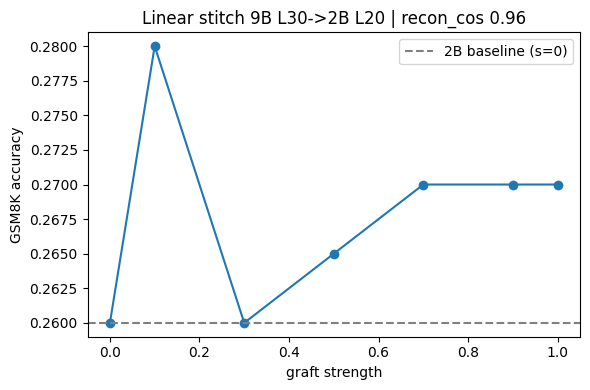

In [11]:
import matplotlib.pyplot as plt
from datasets import load_dataset

def evaluate_gsm8k_linear(stitch, samples, strength=1.0, batch_size=EVAL_BATCH_SIZE):
    correct = total = 0
    target_layer = model_a.model.layers[LIN_LAYER_A]
    target_layer._forward_hooks.clear()
    handle = target_layer.register_forward_hook(dynamic_grafting_hook_projected)
    grafting_context['oracle_basis'] = None
    grafting_context['rescale_graft'] = False
    grafting_context['strength'] = strength
    model_a.eval(); model_b.eval()
    
    try:
        for i in tqdm(range(0, len(samples), batch_size), desc=f"linear s={strength}"):
            b = samples[i:i+batch_size]
            prompts = [generate_gsm8k_prompt(x['question']) for x in b]
            gold = [extract_numerical_answer(x['answer']) for x in b]
            inputs = tokenizer(prompts, return_tensors="pt", padding=True,
                               truncation=True, max_length=512).to(device)
            with torch.no_grad():
                if strength > 0.0:
                    base_b = model_b.model if hasattr(model_b, 'model') else model_b
                    ob = base_b(inputs['input_ids'], attention_mask=inputs['attention_mask'],
                                output_hidden_states=True)
                    grafting_context['current_grafted_activation'] = stitch(
                        ob.hidden_states[LIN_LAYER_B + 1])
                else:
                    grafting_context['current_grafted_activation'] = None
                gen = model_a.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS,
                                       do_sample=False, pad_token_id=tokenizer.eos_token_id)
            resp = tokenizer.batch_decode(gen[:, inputs['input_ids'].shape[1]:],
                                          skip_special_tokens=True)
            for j, r in enumerate(resp):
                p = extract_numerical_answer(r)
                correct += int(p is not None and gold[j] is not None and abs(p - gold[j]) < 0.01)
                total += 1
    finally:
        handle.remove()
        grafting_context.update(strength=0.0, current_grafted_activation=None)
        
    acc = correct / total if total else 0.0
    print(f"-> LINEAR strength {strength}: acc = {acc:.3f} ({correct}/{total})")
    return acc

eval_samples = list(load_dataset("openai/gsm8k", "main", split="test").select(range(200)))
STRENGTHS = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
linear_results = {s: evaluate_gsm8k_linear(linear_stitch, eval_samples, strength=s) for s in STRENGTHS}

print("\n=== LINEAR-STITCH sweep (no SAE) ===")
print(f"recon_cos = {recon_cos:.3f}")
for s in STRENGTHS:
    print(f"  strength {s:>3}: acc {linear_results[s]:.3f}")

print("\n flat at the s=0 baseline -> faithful reconstruct, SAE caused the degradation.")
print(" still drops with strength -> cross-model foreignness / GSM8K states don't align.")

plt.figure(figsize=(6,4))
plt.plot(STRENGTHS, [linear_results[s] for s in STRENGTHS], "-o")
plt.axhline(linear_results[0], ls="--", c="gray", label="2B baseline (s=0)")
plt.xlabel("graft strength"); plt.ylabel("GSM8K accuracy")
plt.title(f"Linear stitch 9B L{LIN_LAYER_B}->2B L{LIN_LAYER_A} | recon_cos {recon_cos:.2f}")
plt.legend(); plt.tight_layout(); plt.savefig("linear_stitch_sweep.png", dpi=140)

import json
json.dump({"recon_cos": recon_cos, "results": {str(k): v for k, v in linear_results.items()},
           "LIN_LAYER_A": LIN_LAYER_A, "LIN_LAYER_B": LIN_LAYER_B},
          open("linear_stitch_results.json", "w"), indent=2)
print("saved linear_stitch_results.json + linear_stitch_sweep.png")